# VehiDE → YOLO-Seg Dataset Preparation

Converts VehiDE's original VIA polygon annotations into YOLO instance-segmentation format (`class_id x1 y1 x2 y2 ... xn yn` per line), for fine-tuning a `-seg` model such as `abdullahg7/cardd-yolov8s`.

**This notebook does not re-collect or re-annotate anything.** VehiDE's original VIA polygon annotations were preserved untouched throughout Milestone 2's bounding-box conversion — this notebook converts those same polygons directly.

**Important correction included here:** the bbox pipeline normalises coordinates against the *original* image dimensions, then pairs them with the *letterboxed and padded* image without adjusting for the padding offset. For any non-square image this silently misaligns labels against the image (verified: a 10% vertical offset on a 1600×1200 test case). This notebook's polygon transform is letterbox-aware and does not have that bug — verified both mathematically and against the actual conversion output (Section 6).

**If you haven't already, check the Milestone 4 bbox dataset for this same issue before trusting that model's recall numbers** — same overlay technique as Section 6 below, adapted for bounding boxes.

**Setup on Kaggle:** attach the **raw** VehiDE dataset (VIA annotation JSONs) as an input — not the Milestone 2 processed dataset. No GPU needed for this notebook; it's pure data conversion.

**Output:** this notebook ends by publishing `/kaggle/working/vehide_seg/` as a new Kaggle Dataset, which the separate fine-tuning notebook consumes as an input — see the last section below.

## 1. Setup

In [15]:
import json, shutil, time
from pathlib import Path
from collections import defaultdict

from PIL import Image

print("Ready — no GPU required for dataset conversion.")

Ready — no GPU required for dataset conversion.


In [16]:
!ls /kaggle/input/

# EDIT: raw VehiDE dataset (must contain the VIA annotation JSONs, not the M2 processed output)
RAW_ROOT = Path("/kaggle/input/datasets/hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection")
ANNOTATION_FILES = ["0Train_via_annos.json", "0Val_via_annos.json"]

PROCESSED_ROOT = Path("/kaggle/input/datasets/m4rcuseryx/vehide-dataset-preprocessed/vehide_processed")


SEG_OUT = Path("/kaggle/working/vehide_seg")
IMG_SIZE = 1280   # matches the M2 weighted-mean sizing decision — kept consistent

print("Raw root exists:", RAW_ROOT.exists())
print("Processed root exists:", PROCESSED_ROOT.exists())

datasets
Raw root exists: True
Processed root exists: True


## 2. Reuse the existing split membership

Read which image stems belong to train/val/test from Milestone 2's split files — not a fresh random split. This keeps this dataset comparable to the bbox model's results and avoids any risk of leaking a test-split image into this dataset's training set.

In [17]:
def read_split(split_name):
    path = PROCESSED_ROOT / "splits" / f"{split_name}.txt"
    stems = set()
    for line in path.read_text().splitlines():
        line = line.strip()
        if line:
            stems.add(Path(line).stem)
    return stems

split_membership = {
    "train": read_split("train"),
    "val": read_split("val"),
    "test": read_split("test"),
}
for name, stems in split_membership.items():
    print(f"{name}: {len(stems)} images (reused from Milestone 2)")

train: 9558 images (reused from Milestone 2)
val: 2048 images (reused from Milestone 2)
test: 2049 images (reused from Milestone 2)


## 3. VIA annotation loading (same class remap as Milestone 2)

Same `VN_TO_EN` / class-id mapping as `scripts/preprocess_images.py`: `torn_body → crack` (kept as its own class), `lost_parts` excluded (no consistent visual signature).

In [18]:
VN_TO_EN = {
    "mat_bo_phan": "lost_parts",
    "rach":        "torn_body",
    "mop_lom":     "dents",
    "tray_son":    "paint_scratches",
    "thung":       "puncture",
    "vo_kinh":     "broken_glass",
    "be_den":      "broken_lamp",
}
EN_TO_CLASS_ID = {
    "lost_parts":     -1,
    "torn_body":       2,
    "dents":           0,
    "paint_scratches": 1,
    "puncture":        5,
    "broken_glass":    4,
    "broken_lamp":     3,
}
CLASS_NAMES = ["dent", "scratch", "crack", "broken_lamp", "shattered_glass", "flat_tyre"]


def _is_via_record(val):
    return isinstance(val, dict) and ("filename" in val or "name" in val) and "regions" in val


def load_via_annotations(json_paths):
    stem_to_regions = {}
    for jp in json_paths:
        with open(jp, encoding="utf-8") as f:
            data = json.load(f)
        if "_via_img_metadata" in data:
            data = data["_via_img_metadata"]
        for key, val in data.items():
            if key.startswith("_via") or not _is_via_record(val):
                continue
            stem = Path(val.get("filename") or val.get("name", "")).stem
            regions = []
            for r in val.get("regions", []):
                shape = r.get("shape_attributes", {})
                attrs = r.get("region_attributes", {})
                xs = shape.get("all_points_x") or shape.get("all_x", [])
                ys = shape.get("all_points_y") or shape.get("all_y", [])
                vn = (attrs.get("class") or attrs.get("damage") or "").strip().lower()
                if xs and ys and len(xs) == len(ys) and len(xs) >= 3:
                    regions.append({"all_x": xs, "all_y": ys, "class": vn})
            stem_to_regions[stem] = regions
    return stem_to_regions


ann_paths = [RAW_ROOT / f for f in ANNOTATION_FILES]
stem_to_regions = load_via_annotations(ann_paths)
print(f"Loaded polygon annotations for {len(stem_to_regions)} images")

Loaded polygon annotations for 13945 images


## 4. Letterbox-aware polygon conversion (the corrected transform)

Normalises each polygon point against the **letterboxed** image — accounting for the scale factor and padding offset — not against the original image dimensions. Verified against a hand-derived test case before use in this notebook.

In [19]:
def letterbox_image(img: Image.Image, size: int = 1280):
    orig_w, orig_h = img.size
    scale = min(size / orig_w, size / orig_h)
    new_w, new_h = round(orig_w * scale), round(orig_h * scale)
    dw, dh = size - new_w, size - new_h
    pad_left, pad_top = dw // 2, dh // 2

    resized = img.convert("RGB").resize((new_w, new_h), Image.LANCZOS)
    canvas = Image.new("RGB", (size, size), (114, 114, 114))
    canvas.paste(resized, (pad_left, pad_top))
    return canvas, scale, pad_left, pad_top


def polygon_to_yolo_seg_line(all_x, all_y, orig_w, orig_h, class_id, scale, pad_left, pad_top, size=1280):
    coords = []
    for x, y in zip(all_x, all_y):
        nx = (x * scale + pad_left) / size
        ny = (y * scale + pad_top) / size
        coords.append(max(0.0, min(1.0, nx)))
        coords.append(max(0.0, min(1.0, ny)))
    coord_str = " ".join(f"{c:.6f}" for c in coords)
    return f"{class_id} {coord_str}"


def find_image_path(stem):
    for ext in (".jpg", ".jpeg", ".png"):
        for p in RAW_ROOT.rglob(f"{stem}{ext}"):
            return p
    return None

## 5. Run the conversion, split-aware

In [20]:
from tqdm import tqdm

stats = defaultdict(int)
class_counts = defaultdict(int)
corrupt_stems = []

for split_name, stems in split_membership.items():
    img_out = SEG_OUT / "images" / split_name
    lbl_out = SEG_OUT / "labels" / split_name
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    for stem in tqdm(sorted(stems), desc=split_name):
        # Resumability: skip stems already converted in a prior (interrupted) run of this cell
        out_img_path = img_out / f"{stem}.jpg"
        out_lbl_path = lbl_out / f"{stem}.txt"
        if out_img_path.exists() and out_lbl_path.exists():
            stats[f"{split_name}_already_done"] += 1
            continue

        regions = stem_to_regions.get(stem)
        img_path = find_image_path(stem)
        if regions is None or img_path is None:
            stats["missing_image_or_annotation"] += 1
            continue

        # Everything that touches this image's pixel data is wrapped together, since
        # PIL's Image.open() only reads the header — truncation/corruption is only
        # detected once .load() runs, which .convert()/.resize() trigger internally.
        try:
            img = Image.open(img_path)
            img.load()  # force full decode now, so a truncated file is caught here,
                        # not partway through letterbox_image() below
            orig_w, orig_h = img.size
            letterboxed, scale, pad_left, pad_top = letterbox_image(img, IMG_SIZE)
        except (OSError, Exception) as e:
            stats["corrupt_image"] += 1
            corrupt_stems.append((stem, str(e)))
            continue

        lines = []
        for r in regions:
            vn = r["class"]
            en = VN_TO_EN.get(vn)
            if en is None:
                stats["unknown_class"] += 1
                continue
            cid = EN_TO_CLASS_ID.get(en, -1)
            if cid == -1:
                stats["excluded_lost_parts"] += 1
                continue
            line = polygon_to_yolo_seg_line(
                r["all_x"], r["all_y"], orig_w, orig_h, cid, scale, pad_left, pad_top, IMG_SIZE
            )
            lines.append(line)
            class_counts[CLASS_NAMES[cid]] += 1

        letterboxed.save(out_img_path, "JPEG", quality=95)
        out_lbl_path.write_text("\n".join(lines))
        stats[f"{split_name}_written"] += 1

print("\nConversion summary:")
for k, v in stats.items():
    print(f"  {k}: {v}")
print("\nInstances per class:")
for c in CLASS_NAMES:
    print(f"  {c}: {class_counts[c]}")

if corrupt_stems:
    print(f"\n{len(corrupt_stems)} corrupt/truncated image(s) skipped:")
    for stem, err in corrupt_stems[:20]:
        print(f"  {stem}: {err}")
    if len(corrupt_stems) > 20:
        print(f"  ... and {len(corrupt_stems) - 20} more")


test: 100%|██████████| 2049/2049 [02:36<00:00, 13.13it/s]


Conversion summary:
  train_already_done: 95
  corrupt_image: 16
  train_written: 9450
  val_written: 2047
  test_written: 2047

Instances per class:
  dent: 0
  scratch: 0
  crack: 0
  broken_lamp: 0
  shattered_glass: 0
  flat_tyre: 0

16 corrupt/truncated image(s) skipped:
  02012020_082351image833616: image file is truncated (21 bytes not processed)
  04052020_152057image59498: broken data stream when reading image file
  04052020_152101image628633: broken data stream when reading image file
  13032020_144737image20659: image file is truncated (0 bytes not processed)
  13032020_144742image419520: broken data stream when reading image file
  13032020_144756image760735: broken data stream when reading image file
  13032020_144759image376956: broken data stream when reading image file
  24032020_091653image573732: broken data stream when reading image file
  24032020_094730image64439: image file is truncated (0 bytes not processed)
  24032020_140438image435324: image file is truncate

## 6. Write `damage-seg.yaml` and sanity-check one converted label against its image

In [21]:
import yaml

yaml_cfg = {
    "path": str(SEG_OUT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES,
}
SEG_DATA_YAML = "/kaggle/working/damage-seg.yaml"
with open(SEG_DATA_YAML, "w") as f:
    yaml.safe_dump(yaml_cfg, f)
print(open(SEG_DATA_YAML).read())

names:
- dent
- scratch
- crack
- broken_lamp
- shattered_glass
- flat_tyre
nc: 6
path: /kaggle/working/vehide_seg
test: images/test
train: images/train
val: images/val



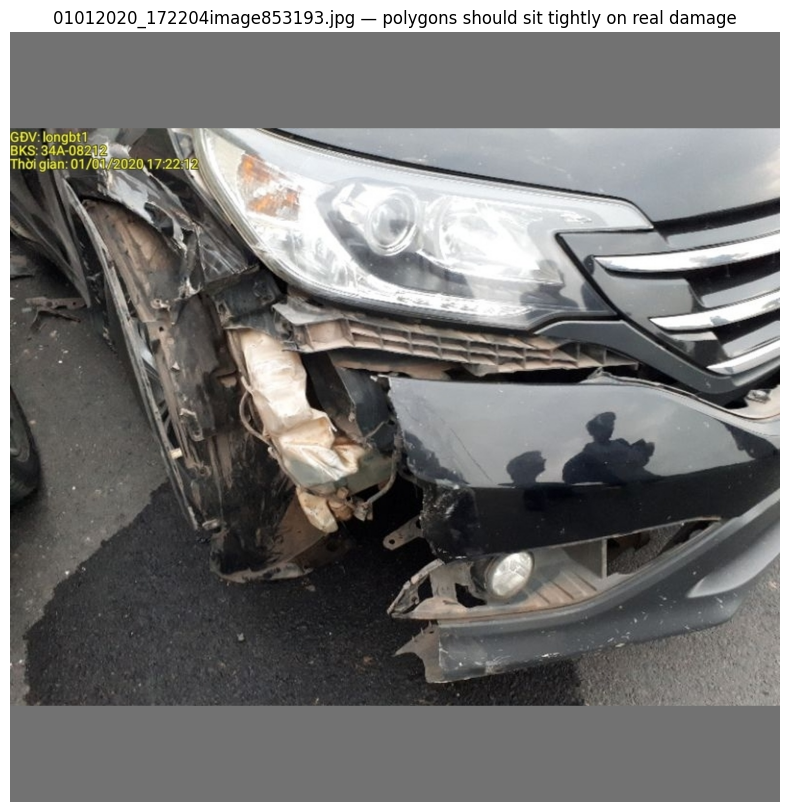

In [22]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

sample_img = sorted((SEG_OUT / "images" / "train").glob("*.jpg"))[0]
sample_lbl = SEG_OUT / "labels" / "train" / (sample_img.stem + ".txt")

img = cv2.cvtColor(cv2.imread(str(sample_img)), cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]
overlay = img.copy()
for line in sample_lbl.read_text().splitlines():
    parts = list(map(float, line.split()))
    cid, coords = int(parts[0]), parts[1:]
    pts = np.array([[coords[i] * w, coords[i + 1] * h] for i in range(0, len(coords), 2)], dtype=np.int32)
    cv2.polylines(overlay, [pts], isClosed=True, color=(0, 255, 0), thickness=3)
    cv2.putText(overlay, CLASS_NAMES[cid], tuple(pts[0]), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

plt.figure(figsize=(10, 10)); plt.imshow(overlay); plt.axis("off")
plt.title(f"{sample_img.name} — polygons should sit tightly on real damage")
plt.show()

## 7. Publish as a Kaggle Dataset

The fine-tuning notebook runs in a separate session and needs this converted dataset as an input, not regenerated each time. Commit this notebook (**Save Version → Save & Run All**), then from the Output tab, **"New Dataset"** (or "Create Dataset from Output") to publish `/kaggle/working/vehide_seg/` and `/kaggle/working/damage-seg.yaml`.

Alternatively, publish via the Kaggle API directly from this notebook:

In [25]:
# import os
# from kaggle_secrets import UserSecretsClient

# secrets = UserSecretsClient()
# os.environ["KAGGLE_USERNAME"] = secrets.get_secret("KAGGLE_USERNAME")
# os.environ["KAGGLE_KEY"] = secrets.get_secret("KAGGLE_KEY")

# PUBLISH_SLUG = "vehide-seg-yolo"   # must be unique to your account
# PUBLISH_ID = f"{os.environ['KAGGLE_USERNAME']}/{PUBLISH_SLUG}"

# # Bundle the yaml alongside the dataset so the fine-tuning notebook has everything in one input
# shutil.copy("/kaggle/working/damage-seg.yaml", SEG_OUT / "damage-seg.yaml")

# (SEG_OUT / "dataset-metadata.json").write_text(json.dumps({
#     "title": "VehiDE Segmentation (YOLO-seg format)",
#     "id": PUBLISH_ID,
#     "licenses": [{"name": "CC0-1.0"}],
# }))

# check = os.system(f"kaggle datasets metadata {PUBLISH_ID} -p /tmp/pub_check 2>/dev/null")
# if check == 0:
#     os.system(f'kaggle datasets version -p {SEG_OUT} -m "update" --dir-mode zip -q')
#     print(f"Updated existing dataset: {PUBLISH_ID}")
# else:
#     os.system(f"kaggle datasets create -p {SEG_OUT} --dir-mode zip -q")
#     print(f"Published new dataset: {PUBLISH_ID}")

# print("\nIn the fine-tuning notebook, attach this as an input:")
# print(f"  {PUBLISH_ID}")